In [6]:
import sys
sys.path.append('../')

from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.datasets import make_friedman1, make_friedman2, make_friedman3
import matplotlib.pyplot as plt
import xgboost as xgb #baseline
from utils import *

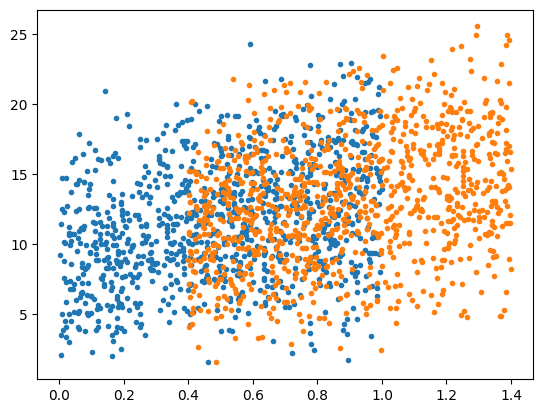

In [7]:
def friedman1(n_samples, noise = 0.0):
    x0 = np.random.uniform(0,1,size=n_samples)
    x1 = np.random.uniform(0,1,size=n_samples)
    x2 = np.random.uniform(0,1,size=n_samples)
    x3 = np.random.uniform(0,1,size=n_samples)
    x4 = np.random.uniform(0,1,size=n_samples)
    X = np.column_stack((x0, x1, x2, x3, x4)) 
    y = 10*np.sin(x0*x1) + 20*(x2 - 0.5)**2 + 10*x3 + 5*x4 + noise*np.random.normal(0,1,size = n_samples) 
    return X, y

def friedman1_altered(n_samples, noise = 0.0):
    x0 = np.random.uniform(0,1,size=n_samples) + 0.4
    x1 = np.random.uniform(0,1,size=n_samples)
    x2 = np.random.uniform(0,1,size=n_samples) 
    x3 = np.random.uniform(0,1,size=n_samples) 
    x4 = np.random.uniform(0,1,size=n_samples)
    X = np.column_stack((x0, x1, x2, x3, x4)) 
    y = 10*np.sin(x0*x1) + 20*(x2 - 0.5)**2 + 10*x3 + 5*x4 + noise*np.random.normal(0,1,size = n_samples)
    return X, y

X, y = friedman1(1000, noise = 0.0)
X_altered, y_altered= friedman1_altered(1000, noise=0.0)

plt.plot(X[:,0], y, '.')
plt.plot(X_altered[:,0], y_altered, '.')
plt.show()


In [8]:
X_target_test, y_target_test = friedman1(n_samples=10000, noise=0.1) 
X_target_train, y_target_train = friedman1(n_samples=300, noise=0.1)
X_source_train, y_source_train = friedman1_altered(n_samples=10000, noise=0.1) 
X_source_train.shape

(10000, 5)

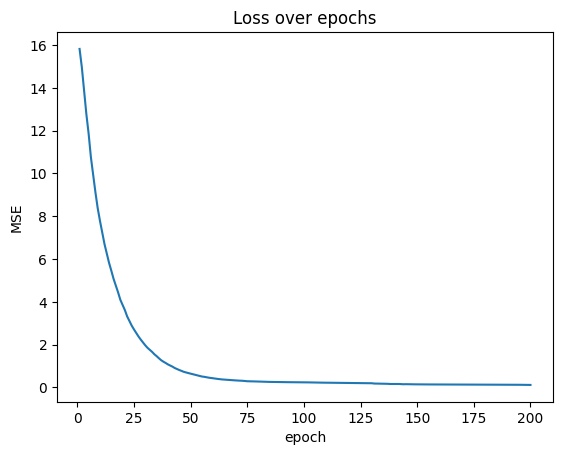

0.6599797419021448


In [9]:
#MTreeBoost is under development
fiter = LSTransferTreeBoost(epochs=200, v=0.2, decay_factor=0.96)
y = np.concatenate((y_source_train, y_target_train))
fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, show_curves=True)
rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
print(rmse)

In [10]:
params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 2,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
}

def train_xgboost(data_train, labels_train, boosting_rounds):

    dtrain = xgb.DMatrix(data_train, label=labels_train)

    # Train with evaluation set and early stopping
    evallist = [(dtrain, 'train')]

    bst = xgb.train(params, dtrain, num_boost_round=boosting_rounds, evals=evallist)

    return bst

def test_xgboost(data_test, bst):
    
    dtest = xgb.DMatrix(data_test)
    preds = bst.predict(dtest)
    return preds

X = np.concatenate((X_source_train, X_target_train))
bst = train_xgboost(X_target_train, y_target_train, boosting_rounds=200)
preds = test_xgboost(X_target_test, bst)
rmse = compute_rmse(preds, y_target_test)
print(rmse)

[0]	train-rmse:3.89731
[1]	train-rmse:3.71271
[2]	train-rmse:3.54481
[3]	train-rmse:3.39938
[4]	train-rmse:3.26630
[5]	train-rmse:3.13909
[6]	train-rmse:3.02708
[7]	train-rmse:2.91800
[8]	train-rmse:2.82218
[9]	train-rmse:2.73236
[10]	train-rmse:2.64475
[11]	train-rmse:2.56937
[12]	train-rmse:2.49118
[13]	train-rmse:2.42113
[14]	train-rmse:2.35265
[15]	train-rmse:2.29304
[16]	train-rmse:2.22205
[17]	train-rmse:2.16110
[18]	train-rmse:2.10401
[19]	train-rmse:2.05475
[20]	train-rmse:2.00400
[21]	train-rmse:1.94163
[22]	train-rmse:1.88602
[23]	train-rmse:1.83993
[24]	train-rmse:1.79617
[25]	train-rmse:1.74550
[26]	train-rmse:1.70606
[27]	train-rmse:1.65846
[28]	train-rmse:1.62095
[29]	train-rmse:1.57852
[30]	train-rmse:1.54335
[31]	train-rmse:1.50428
[32]	train-rmse:1.46719
[33]	train-rmse:1.43533
[34]	train-rmse:1.39414
[35]	train-rmse:1.36616
[36]	train-rmse:1.33477
[37]	train-rmse:1.30846
[38]	train-rmse:1.27770
[39]	train-rmse:1.25498
[40]	train-rmse:1.22799
[41]	train-rmse:1.19834
[4